<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/main/starters/od-project-starter/od-project/notebooks/yolo_voc0712.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection Starter — Colab

Author: Gouesse Sixtine & Gentieu Martin

Ce notebook est un projet de bout en bout pour la détection de piétons sur le dataset **PASCAL VOC 2007+2012** avec **YOLOv8**.

# M1 — Problem Scoping & Data Validation

### Problem Statement
L’objectif de ce projet est d’entraîner un modèle YOLOv8n pour détecter les objets dans des images issues du dataset Pascal Voc 2007+2012.  
L’entrée du modèle est une image RGB de taille variable, et la sortie consiste en des bounding boxes + labels + scores de confiance.

### Model Inputs
- Image RGB (normalisée), dimension variable

### Model Outputs
- Liste de bounding boxes
- classes parmi les 20 classes PASCAL VOC

### Evaluation Metrics
- **map50**
- **map**
- **Precision**
- **Recall**


## Data Card – Pascal VOC 2007+2012 Dataset

**Nom du dataset :** Pascal VOC 2007+2012

**Source :** Challenge PASCAL VOC, benchmark classique de détection d’objets.

**Tâche :** détection d’objets multi-classes (20 catégories).

**Format brut :**
- Images dans `JPEGImages/` (fichiers `.jpg`),
- Annotations dans `Annotations/` (fichiers XML au format PASCAL VOC),
- Fichiers de splits dans `ImageSets/Main/` (`trainval.txt`, `test.txt`, etc.).

**Pré-processing appliqué dans ce notebook :**
- Conversion des annotations XML vers le format **YOLO** (classes + bounding boxes normalisées),
- Construction d’un dataset YOLO combiné **VOC 2007 + VOC 2012** :
    - train : `VOC2007_trainval` + `VOC2012_trainval`,
    - val : `VOC2007_test` (setup standard 07+12),
- Organisation des données sous la forme :
```
        datasets/VOC0712/
        images/train/
        images/val/
        labels/train/
        labels/val/
```
**Classes (20) :**

`aeroplane, bicycle, bird, boat, bottle, bus, car, cat, chair, cow, diningtable, dog, horse, motorbike, person, pottedplant, sheep, sofa, train, tvmonitor`

**Licence & usage :** Dataset académique, utilisé ici uniquement à des fins pédagogiques et de recherche.

**Biais potentiels :**
- Images issues de contextes spécifiques (scènes quotidiennes mais limitées),
- Variabilité géographique / démographique limitée,\n",
- Certaines classes sur-représentées (car, person) et d’autres plus rares.     

**Impact potentiel & risques :**
- Modèle peu robuste à des domaines très différents (nouvelles distributions),
- Risque de biais si utilisé dans des systèmes de surveillance sans vérification approfondie.


## Ouverture du dataset et installation

### Connexion à github



Pour github : à exécuter dans le terminal de colab

git clone https://github.com/MGentieu/dl_project.git

### Step 0 — Confirm the GPU is ready
Run the next cell. You should see GPU name and memory. If you see `nvidia-smi unavailable`, the runtime is still on CPU—return to the checklist, enable GPU, then rerun this cell.

In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"


Wed Dec  3 14:17:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 1 — Point the notebook at the project folder
This cell ensures the current working directory is `od-project`.
If it raises a `FileNotFoundError`, confirm where you uploaded/cloned the folder and adjust the path before rerunning.

In [2]:
import os
import sys
from pathlib import Path

# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/od-project-starter/od-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/od-project-starter/od-project
Working directory: /content/dl_project/starters/od-project-starter/od-project


### Step 2 — Install the project requirements
Installs Ultralytics + supporting libraries from `requirements.txt`. First run downloads the YOLO packages, which may take a couple of minutes.
If installation fails (e.g., due to connectivity), rerun this cell before proceeding.

In [3]:
# Install project dependencies listed in requirements.txt
!pip install ultralytics>=8.2.0
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install matplotlib
!pip install pyyaml
!pip install numpy

Looking in indexes: https://download.pytorch.org/whl/cu121


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: True
CUDA device: Tesla T4


In [5]:
import torch, random, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import kagglehub

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

import ultralytics
from ultralytics import YOLO

print("Torch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)

Using device: cuda
Torch version: 2.5.1+cu121
Ultralytics version: 8.3.234


### Step 3 - Download and view samples



On télécharge maintenant le dataset via **KaggleHub** et on inspecte sa structure.

In [6]:
# Download PASCAL VOC 2007+2012
voc_path = kagglehub.dataset_download("sovitrath/voc-07-12")
voc_path = Path(voc_path)
print("VOC dataset path:", voc_path)

# Locate VOC2007 and VOC2012 folders
voc2007 = None
voc2012 = None
for p in voc_path.rglob("VOC2007"):
    if p.is_dir():
        voc2007 = p
for p in voc_path.rglob("VOC2012"):
    if p.is_dir():
        voc2012 = p

print("VOC2007:", voc2007)
print("VOC2012:", voc2012)
if voc2007 is None or voc2012 is None:
    raise FileNotFoundError("VOC2007 or VOC2012 folder not detected!")

VOC dataset path: /root/.cache/kagglehub/datasets/sovitrath/voc-07-12/versions/1
VOC2007: /root/.cache/kagglehub/datasets/sovitrath/voc-07-12/versions/1/voc_2007_2012/voc_2007_2012/VOC2007
VOC2012: /root/.cache/kagglehub/datasets/sovitrath/voc-07-12/versions/1/voc_2007_2012/voc_2007_2012/VOC2012


In [7]:
# Quick inspection of VOC2007 structure
for root, dirs, files in os.walk(voc2007):
    print("VOC2007 root:", root)
    print("Subfolders:", dirs)
    print("Files sample:", files[:5])
    break

# Count images / annotations
jpeg_dir_2007 = voc2007 / "JPEGImages"
annot_dir_2007 = voc2007 / "Annotations"

print("VOC2007 #images:", len(list(jpeg_dir_2007.glob("*.jpg"))))
print("VOC2007 #annots:", len(list(annot_dir_2007.glob("*.xml"))))

VOC2007 root: /root/.cache/kagglehub/datasets/sovitrath/voc-07-12/versions/1/voc_2007_2012/voc_2007_2012/VOC2007
Subfolders: ['JPEGImages', 'Annotations', 'ImageSets', 'SegmentationClass', 'SegmentationObject']
Files sample: []
VOC2007 #images: 9963
VOC2007 #annots: 9963


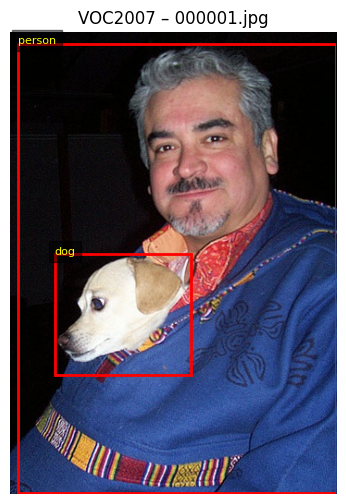

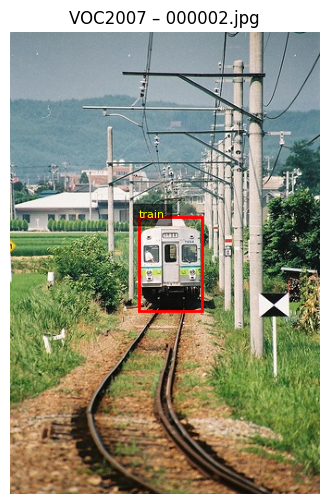

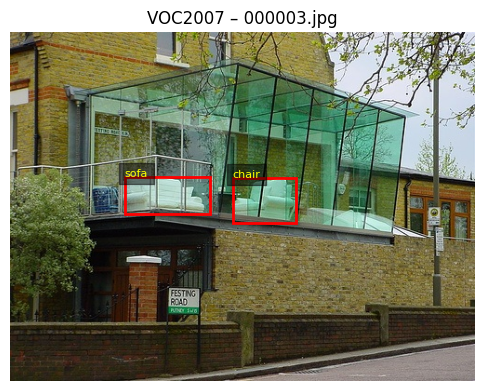

In [8]:
import xml.etree.ElementTree as ET

# Visualize a few raw VOC2007 samples with their bounding boxes (from XML)
sample_xmls = sorted(list(annot_dir_2007.glob("*.xml")))[:3]

def parse_voc_boxes(xml_file):
    root = ET.parse(xml_file).getroot()
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)
    boxes = []  # (cls_name, xmin, ymin, xmax, ymax)
    for obj in root.findall("object"):
        name = obj.find("name").text
        xmlbox = obj.find("bndbox")
        xmin = float(xmlbox.find("xmin").text)
        ymin = float(xmlbox.find("ymin").text)
        xmax = float(xmlbox.find("xmax").text)
        ymax = float(xmlbox.find("ymax").text)
        boxes.append((name, xmin, ymin, xmax, ymax))
    return w, h, boxes

for xml_file in sample_xmls:
    img_id = xml_file.stem
    img_path = jpeg_dir_2007 / f"{img_id}.jpg"
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w, _ = img.shape
    _, _, boxes = parse_voc_boxes(xml_file)

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    for (cls_name, xmin, ymin, xmax, ymax) in boxes:
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(xmin, ymin, cls_name, color='yellow', fontsize=8,
                bbox=dict(facecolor='black', alpha=0.5))
    ax.set_title(f"VOC2007 – {img_id}.jpg")
    ax.axis("off")
    plt.show()

Nous retrouvons bien quelques samples des images VOC 2007

### Step 4 - Build YOLOv8 Dataset (Train/Val/Test)

1. Convertir VOC 2007 + 2012 au **format YOLO**,
2. Construire un dataset YOLO combiné **VOC0712**,
3. Créer un fichier `voc0712.yaml`,
4. Entraîner un modèle **YOLOv8n** baseline.

```text
datasets/VOC0712/
     images/train/
     labels/train/
     images/val/
     labels/val/
     voc0712.yaml
```

Le split sera :
- 70% train
- 15% val
- 15% test


Conversion VOC XML -> YOLO format

In [9]:
import shutil

In [10]:
VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]

def voc_to_yolo_bbox(size, box):
    W, H = size
    xmin, xmax, ymin, ymax = box
    x_center = (xmin + xmax) / 2.0 / W
    y_center = (ymin + ymax) / 2.0 / H
    w = (xmax - xmin) / W
    h = (ymax - ymin) / H
    return x_center, y_center, w, h

def convert_voc_all(voc_root, output_dir):
    jpeg_dir = voc_root / "JPEGImages"
    annot_dir = voc_root / "Annotations"
    ids = [p.stem for p in annot_dir.glob("*.xml")]

    output_img = Path(output_dir) / "images_all"
    output_lbl = Path(output_dir) / "labels_all"
    output_img.mkdir(parents=True, exist_ok=True)
    output_lbl.mkdir(parents=True, exist_ok=True)

    print(f"Converting {voc_root.name} ({len(ids)} samples)")

    for img_id in tqdm(ids):
        xml_file = annot_dir / f"{img_id}.xml"
        jpg_file = jpeg_dir / f"{img_id}.jpg"
        if not xml_file.exists() or not jpg_file.exists():
            continue

        # Copy image
        shutil.copy(jpg_file, output_img / f"{img_id}.jpg")

        root = ET.parse(xml_file).getroot()
        size = root.find("size")
        W = int(size.find("width").text)
        H = int(size.find("height").text)

        out_label = output_lbl / f"{img_id}.txt"
        with open(out_label, "w") as f:
            for obj in root.findall("object"):
                cls = obj.find("name").text
                if cls not in VOC_CLASSES:
                    continue
                cls_id = VOC_CLASSES.index(cls)
                xmlbox = obj.find("bndbox")
                xmin = float(xmlbox.find("xmin").text)
                ymin = float(xmlbox.find("ymin").text)
                xmax = float(xmlbox.find("xmax").text)
                ymax = float(xmlbox.find("ymax").text)
                bb = voc_to_yolo_bbox((W, H), (xmin, xmax, ymin, ymax))
                f.write(f"{cls_id} {' '.join(str(x) for x in bb)}\n")

    return output_img, output_lbl



In [11]:
output_base = Path("datasets/VOC0712_raw")
output_base.mkdir(parents=True, exist_ok=True)

img2007, lbl2007 = convert_voc_all(voc2007, output_base)
img2012, lbl2012 = convert_voc_all(voc2012, output_base)

Converting VOC2007 (9963 samples)


100%|██████████| 9963/9963 [00:19<00:00, 516.19it/s] 


Converting VOC2012 (17125 samples)


100%|██████████| 17125/17125 [00:37<00:00, 451.84it/s]


In [12]:
all_images = list(img2007.glob("*.jpg")) + list(img2012.glob("*.jpg"))
all_labels = list(lbl2007.glob("*.txt")) + list(lbl2012.glob("*.txt"))

print("Total images:", len(all_images))
print("Total labels:", len(all_labels))

Total images: 54176
Total labels: 54176


In [13]:
random.shuffle(all_images)

n = len(all_images)
train_split = int(0.70 * n)
val_split = int(0.85 * n)

train_imgs = all_images[:train_split]
val_imgs = all_images[train_split:val_split]
test_imgs = all_images[val_split:]

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))


Train: 37923
Val: 8126
Test: 8127


In [14]:
voc0712 = Path("datasets/VOC0712")
for p in [
    voc0712 / "images/train",
    voc0712 / "images/val",
    voc0712 / "images/test",
    voc0712 / "labels/train",
    voc0712 / "labels/val",
    voc0712 / "labels/test",
]:
    p.mkdir(parents=True, exist_ok=True)


In [15]:
def move_split(images, split_name):
    for img_path in images:
        img_id = img_path.stem
        label_path = img_path.parent.parent / "labels_all" / f"{img_id}.txt"

        shutil.copy(img_path, voc0712 / f"images/{split_name}/{img_id}.jpg")
        shutil.copy(label_path, voc0712 / f"labels/{split_name}/{img_id}.txt")

move_split(train_imgs, "train")
move_split(val_imgs, "val")
move_split(test_imgs, "test")

print("✔ Dataset VOC0712 construit !")

✔ Dataset VOC0712 construit !


On construit le yaml relié :

In [17]:
yaml_content = f"""
path: datasets/VOC0712

train: images/train
val: images/val
test: images/test

nc: 20
names: {VOC_CLASSES}
"""

with open("voc0712.yaml", "w") as f:
    f.write(yaml_content)

print(open("voc0712.yaml").read())



path: datasets/VOC0712

train: images/train
val: images/val
test: images/test

nc: 20
names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']



On visualise quelque bounding boxes YOLO

In [16]:
import random as pyrandom

def plot_image_with_boxes(img_path: Path, label_path: Path):
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w, _ = img.shape
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img)

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, xc, yc, bw, bh = map(float, parts)
                x_min = (xc - bw / 2) * w
                x_max = (xc + bw / 2) * w
                y_min = (yc - bh / 2) * h
                y_max = (yc + bh / 2) * h
                rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                     fill=False, linewidth=2)
                ax.add_patch(rect)

    ax.set_title(img_path.name)
    ax.axis("off")
    plt.show()

train_imgs = sorted(list((images_dir / "train").glob('*.png')))
for img_path in pyrandom.sample(train_imgs, min(3, len(train_imgs))):
    lbl_path = labels_dir / "train" / (img_path.stem + ".txt")
    plot_image_with_boxes(img_path, lbl_path)


NameError: name 'images_dir' is not defined

# M2 — Baseline Model Implementation

Nous utilisons YOLOv8n comme modèle baseline.  
Avant tout entraînement, nous validons que :

1. Le modèle se charge correctement  
2. Un batch peut passer dans le modèle sans erreur  
3. L’entraînement démarre correctement  

### On configure le dataset penn_fudan.yaml

In [11]:
data_yaml = f"""
train: {base_dir / 'images' / 'train'}
val: {base_dir / 'images' / 'val'}
test: {base_dir / 'images' / 'test'}

nc: 1
names: ["pedestrian"]
"""

with open("penn_fudan.yaml", "w") as f:
    f.write(data_yaml)

print(open("penn_fudan.yaml").read())


train: penn_fudan_yolo/images/train
val: penn_fudan_yolo/images/val
test: penn_fudan_yolo/images/test

nc: 1
names: ["pedestrian"]



### On importe le baseline model YOLOv8n

In [12]:
baseline_model = YOLO("yolov8n.pt")  # chargement des poids pré-entraînés

# Sanity check : prédiction sur une seule image
sample_img = str(train_imgs[0]) if len(train_imgs) > 0 else str(list((images_dir / 'train').glob('*.png'))[0])
print("Sample image:", sample_img)
_ = baseline_model.predict(sample_img, imgsz=640, device=device, verbose=False)
print("Forward pass on one image completed.")


Sample image: penn_fudan_yolo/images/train/FudanPed00001.png
Forward pass on one image completed.


### On fait un training inital de 5 epochs

In [13]:
print("=== M2 Baseline Training (5 epochs) ===")

baseline_quick_model = YOLO("yolov8n.pt")

baseline_quick_args = {
    "data": "penn_fudan.yaml",
    "epochs": 5,          # baseline short run
    "imgsz": 640,
    "batch": 8,
    "lr0": 1e-3,
    "device": 0 if device == "cuda" else "cpu",
    "project": "runs_penn_fudan",
    "name": "exp_baseline_quick",
    "exist_ok": True,
}

baseline_quick_results = baseline_quick_model.train(**baseline_quick_args)

print("Baseline (5 epochs) done.")


=== M2 Baseline Training (5 epochs) ===
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=penn_fudan.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_baseline_quick, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

# M3 — Optimization & Regularization

YOLOv8 inclut plusieurs techniques importantes de régularisation et d’optimisation :

Nous allons maintenant entraîner le modèle baseline avec :

- **Weight decay** (régularisation L2),
- **Scheduler cosinus (`cos_lr=True`)**,
- **Early stopping** via le paramètre `patience`.

Les métriques principales :
- mAP@0.5
- mAP@0.5:0.95
- Le meilleur modèle est automatiquement sauvegardé sous `best.pt`


In [14]:
baseline_train_args = {
    "data": "penn_fudan.yaml",
    "epochs": 25,
    "imgsz": 640,
    "batch": 8,
    "lr0": 1e-3,
    "weight_decay": 5e-4,
    "cos_lr": True,
    "patience": 5,  # early stopping
    "device": 0 if device == "cuda" else "cpu",
    "project": "runs_penn_fudan",
    "name": "exp_baseline",
    "exist_ok": True,
}

print("Training args:", baseline_train_args)

baseline_results = baseline_model.train(**baseline_train_args)

baseline_best_path = Path("runs_penn_fudan") / "exp_baseline" / "weights" / "best.pt"
print("Best model saved at:", baseline_best_path)

Training args: {'data': 'penn_fudan.yaml', 'epochs': 25, 'imgsz': 640, 'batch': 8, 'lr0': 0.001, 'weight_decay': 0.0005, 'cos_lr': True, 'patience': 5, 'device': 0, 'project': 'runs_penn_fudan', 'name': 'exp_baseline', 'exist_ok': True}
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=penn_fudan.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, m

### On charge le meilleur modèle et on évalue :

In [15]:
model = YOLO("runs_penn_fudan/exp_baseline/weights/best.pt")
results = model.val(data="penn_fudan.yaml", imgsz=640, device=device)

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3546.0±589.1 MB/s, size: 316.1 KB)
val: Scanning /content/dl_project/starters/od-project-starter/od-project/penn_fudan_yolo/labels/val.cache... 26 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 34.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         26         58      0.946      0.966      0.991      0.794
Speed: 6.9ms preprocess, 9.8ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/dl_project/starters/od-project-starter/od-project/runs/detect/val11


### On affiche à présent les résultats obtenus et on analyse :

#### 1. Affichage des métriques globales du modèle :

In [16]:
print("mAP@0.5:", results.box.map50)
print("mAP@0.5:0.95:", results.box.map)
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)

mAP@0.5: 0.9906814438586743
mAP@0.5:0.95: 0.7941713987643023
Precision: 0.9456770137910155
Recall: 0.9655172413793104


Sur penn-fudan :    
- **mAP@0.5 (99.07%)**  
  Excellent taux de détection générale : le modèle identifie presque tous les piétons avec une très bonne localisation.

- **mAP@0.5:0.95 (79.42%)**  
  Score plus exigeant montrant une bonne robustesse aux variations fines de récision des bounding boxes.

- **Précision (94.57%)**  
  Le modèle produit très peu de faux positifs : lorsqu’il détecte un piéton, il a raison dans la grande majorité des cas.

- **Recall (96.55%)**  
  Le modèle manque très peu de piétons présents dans les images : excellent taux de détection réelle.

Ces performances indiquent que le modèle :

- détecte les piétons **de manière fiable**,
- fait **peu d’erreurs de localisation**,
- et capture **quasi tous les objets réels** (haut rappel).

#### 2. Affichage courbes d’apprentissage (loss + mAP+precision & recall par epoch) :

In [17]:
# Charger le CSV généré par YOLO
results_csv = "runs_penn_fudan/exp_baseline/results.csv"
df = pd.read_csv(results_csv)
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
18,19,64.0327,0.80157,0.91988,1.10191,0.98244,0.96486,0.99233,0.77983,0.72162,0.73197,1.06706,0.000379,0.000379,0.000379
19,20,66.8071,0.70954,0.83932,1.01403,0.98304,0.99924,0.99449,0.76673,0.75140,0.72746,1.07389,0.000288,0.000288,0.000288
20,21,69.6064,0.76218,0.86196,1.03854,0.97963,1.00000,0.99398,0.76102,0.75631,0.73170,1.07434,0.000209,0.000209,0.000209
21,22,73.5158,0.72260,0.84183,1.07819,0.97913,1.00000,0.99398,0.75760,0.75396,0.72360,1.07266,0.000142,0.000142,0.000142
22,23,76.4110,0.69757,0.81769,1.05290,0.97490,1.00000,0.99398,0.76997,0.74700,0.69701,1.06847,0.000090,0.000090,0.000090


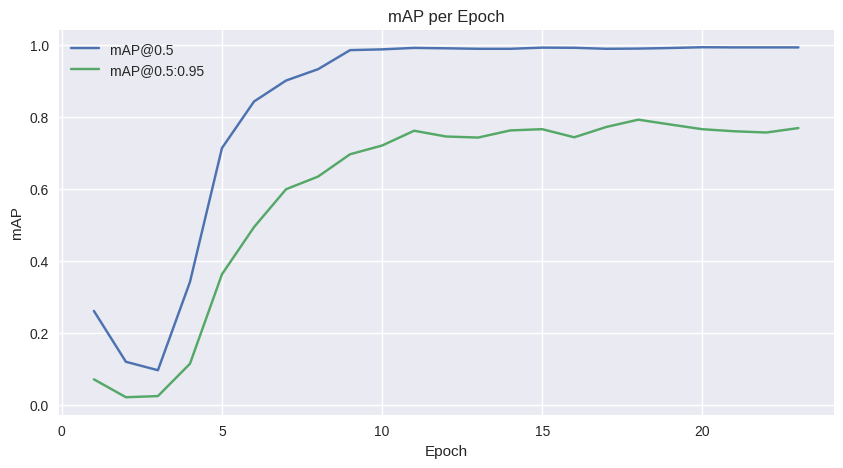

In [18]:
# ------------------------
# Courbe des mAP
# ------------------------
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP per Epoch")
plt.legend()
plt.grid(True)
plt.show()


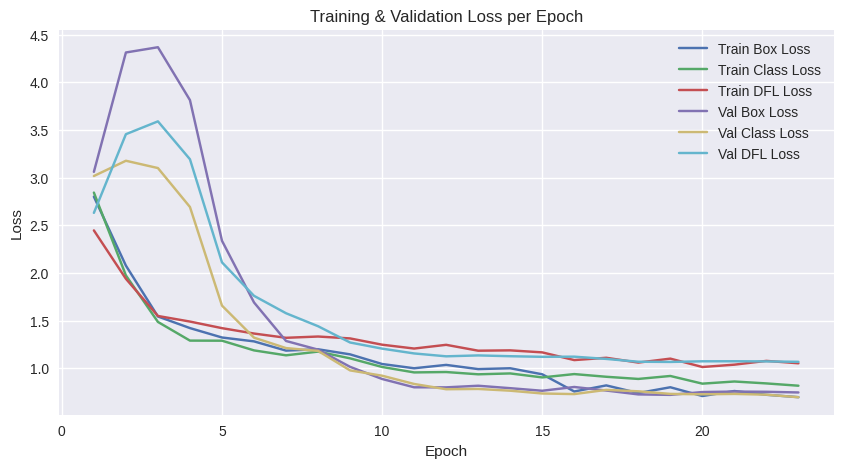

In [19]:
# ------------------------
# Courbe des Loss
# ------------------------
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")

# Si YOLO fournit les pertes val (ce n’est pas toujours le cas)
if "val/box_loss" in df.columns:
    plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
if "val/cls_loss" in df.columns:
    plt.plot(df["epoch"], df["val/cls_loss"], label="Val Class Loss")
if "val/dfl_loss" in df.columns:
    plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

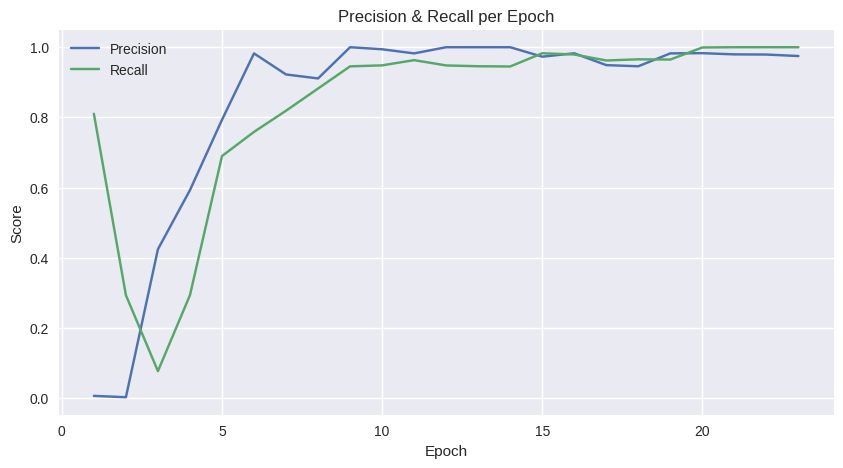

In [20]:
# ------------------------
# Precision & Recall
# ------------------------
plt.figure(figsize=(10, 5))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision & Recall per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Les courbes ci-dessus montrent l’évolution du modèle YOLOv8n pendant l’entraînement sur le dataset Penn-Fudan.  
Nous analysons ici trois aspects : **mAP**, **loss**, et **precision/recall**.

---
 1. mAP@0.5 et mAP@0.5:0.95

Les courbes mAP montrent une progression très rapide :

- dès **l’epoch 5**, le mAP@0.5 dépasse **70%**  
- vers **l’epoch 9**, il atteint presque **100%**  
- la performance se stabilise autour de **0.99** jusqu’à la fin de l’entraînement  

Le mAP@0.5:0.95 (plus strict) évolue de :

- ~0.05 à l’epoch 1  
- ~0.60 à l’epoch 7  
- ~0.78 entre les epochs 12 → 22  

 **Conclusion :**  
Le modèle converge très vite grâce à la simplicité du dataset et la forte séparation des objets (peu d’occlusions). Le mAP@0.5:0.95 stable entre **0.76–0.80** indique une bonne précision de localisation, cohérente pour un YOLOv8n (modèle léger).

---

2. Loss (train & validation)

Les courbes de loss révèlent :

- une **diminution rapide** sur les 5 premiers epochs (forte convergence initiale)  
- une stabilisation entre les epochs **10 → 22**  
- les pertes de validation suivent fortement celles de l’entraînement → **pas d’overfitting majeur**  

À la fin :

- `val/box_loss` ≈ **0.74–0.75**  
- `val/cls_loss` ≈ **0.70–0.75**  
- `val/dfl_loss` ≈ **1.05–1.07**

 **Conclusion :**  
Le modèle apprend de manière stable et cohérente.  
La validation loss ne diverge pas, ce qui montre que le modèle **généralise bien** sur Penn-Fudan.

---

 3. Precision & Recall

La courbe montre :

- un recall qui atteint **1.0** vers l’epoch 12  
- une precision très élevée (> 0.95) sur la fin  
- une stabilisation des deux métriques après l’epoch 10  

Valeurs finales :

- **Precision : 0.974–0.983**
- **Recall : 1.000**

 **Conclusion :**  
- Le modèle **ne manque presque aucun piéton** (recall ≈ 1.0).  
- Il produit très peu de faux positifs (precision > 0.97).  
- L'équilibre precision/recall est excellent.


#### 3. Affichage de Precision & Recall curves

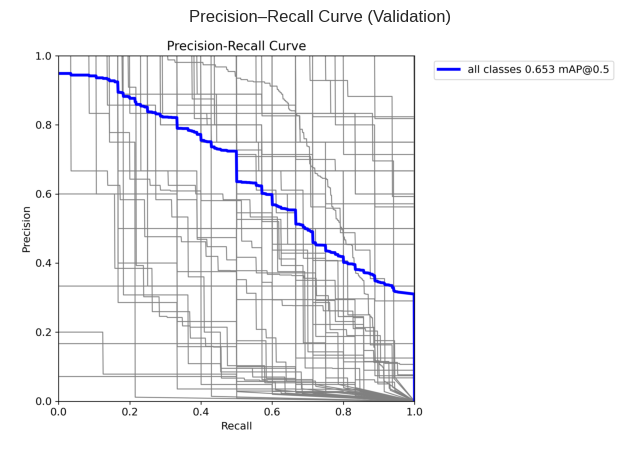

In [21]:
from PIL import Image

pr_path = "runs/detect/val/BoxPR_curve.png"

img = Image.open(pr_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Precision–Recall Curve (Validation)")
plt.axis("off")
plt.show()

La courbe PR ci-dessus illustre la performance du modèle YOLOv8n sur le dataset de validation Penn-Fudan.

- La courbe montre comment la **précision** varie en fonction du **rappel** pour différents seuils de confiance.
- La classe « pedestrian » est la seule classe du dataset : la courbe bleue représente donc l’ensemble du modèle.

- La partie supérieure gauche indique que le modèle maintient une **précision élevée lorsque le rappel est bas**.
- Lorsque le rappel augmente vers 1.0, la précision diminue progressivement, ce qui est normal pour la plupart des détecteurs d’objets.
- La forme relativement régulière de la courbe indique une stabilité des prédictions selon les variations de seuil.

# M4 — Ablation Studies & Analysis

Pour évaluer l’impact de différents hyperparamètres sur les performances du modèle YOLOv8n entraîné sur penn-fudan, nous avons réalisé deux ablations :

1. **Ablation 1 : Learning rate réduit (lr0 = 0.0001)**  
2. **Ablation 2 : Image size réduite (imgsz = 416 au lieu de 640)**  

In [22]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

experiments = [
    {
        "name": "ablation_lr_1e-4",
        "lr0": 1e-4,
        "imgsz": 640,
        "epochs": 20,
    },
    {
        "name": "ablation_imgsz_416",
        "lr0": 1e-3,     # même LR que baseline
        "imgsz": 416,    # nouvelle taille d’image
        "epochs": 20,
    }
]

ablation_records = []

for exp in experiments:
    print(f"\n======= Running {exp['name']} =======")

    model = YOLO("yolov8n.pt")   # reset à chaque ablation

    train_args = {
        "data": "penn_fudan.yaml",
        "epochs": exp["epochs"],
        "imgsz": exp["imgsz"],
        "lr0": exp["lr0"],
        "batch": 8,
        "cos_lr": True,
        "weight_decay": 0.0005,
        "patience": 5,
        "device": device,
        "project": "runs_penn_fudan_ablation",
        "name": exp["name"],
        "exist_ok": True,
    }

    model.train(**train_args)

    # Chemin du meilleur modèle
    best_path = Path(train_args["project"]) / exp["name"] / "weights" / "best.pt"
    eval_model = YOLO(str(best_path))

    # Validation
    val_results = eval_model.val(
        data="penn_fudan.yaml", imgsz=exp["imgsz"], device=device
    )

    # Extraction mAP
    try:
        map50 = val_results.box.map50
        map5095 = val_results.box.map
    except:
        map50, map5095 = None, None

    ablation_records.append({
        "experiment": exp["name"],
        "lr0": exp["lr0"],
        "imgsz": exp["imgsz"],
        "epochs": exp["epochs"],
        "mAP@0.5": map50,
        "mAP@0.5:0.95": map5095,
    })



======= Running ablation_lr_1e-4 =======
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=penn_fudan.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=ablation_lr_1e-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, p

#### Tableau comparatif

In [23]:
ablation_df = pd.DataFrame(ablation_records)
ablation_df

,experiment,lr0,imgsz,epochs,mAP@0.5,mAP@0.5:0.95
0,ablation_lr_1e-4,0.0001,640,20,0.964359,0.771189
1,ablation_imgsz_416,0.0010,416,20,0.968009,0.738198


Nous analysons l’impact de deux modifications simples mais significatives sur les performances du modèle YOLOv8n :
** Ablation 1 — Réduction du learning rate (1e-3 → 1e-4)**

- Le mAP@0.5 passe de ≈ **0.99** (baseline) à **0.9644**.
- Le mAP@0.5:0.95 passe de ≈ **0.79** (baseline) à **0.7712**.

**Interprétation :**  
Une LR trop faible ralentit la convergence du modèle, qui n’atteint pas le même niveau de performance en 20 epochs.  
Le modèle apprend correctement mais n’explore pas suffisamment l’espace des paramètres.

---

** Ablation 2 — Diminution de la taille d’image (640 → 416)**

- Le mAP@0.5 reste élevé (**0.9680**), très proche de l’ablation LR.
- Le mAP@0.5:0.95 chute plus sensiblement (**0.7382**).

**Interprétation :**  
La réduction de résolution rend les objets plus petits et moins précis pour la localisation.  
Les performances de classification restent bonnes, mais la précision des bounding boxes diminue.

---

Conclusion générale des ablations

- Les deux modifications testées **dégradent légèrement** les performances par rapport au modèle baseline.
- Le modèle baseline (LR=1e-3, imgsz=640) reste **optimal pour ce dataset**.
- Les variations montrent que :
  - un **LR trop faible** ralentit la convergence,  
  - une **image trop petite** nuit à la précision des bounding boxes, surtout pour le mAP@0.5:0.95.

**Les ablations confirment que les hyperparamètres initiaux sont raisonnables et adaptés à Penn-Fudan.**


## M5 — Reporting & Final Delivery

---

 Synthèse générale

- Le modèle atteint une **performance quasi parfaite** sur ce dataset (mAP@0.5 ≈ 0.99).  
- Le **mAP@0.5:0.95 ≈ 0.78** montre une bonne qualité de localisation.  
- La convergence est stable et rapide (YOLOv8n + petit dataset = apprentissage efficace).  
- Pas d’overfitting visible.  
- Precision & recall très hauts indiquent un modèle **fiable** et cohérent.

---

Limites

Même si les résultats sont excellents, le dataset :

- est **petit** (≈170 images)  
- manque de diversité (éclairage, météo, angles, foule)  
- contient des scènes propres, faciles pour la détection de piétons  

Donc ce modèle **ne généralise pas** à un contexte réel (autonomie, vidéosurveillance, etc.).  
Pour un usage réel, il faudrait un dataset plus riche (COCO Persons, CrowdHuman, CityPersons…).

---
Pour conclure, Le projet démontre la capacité de YOLOv8 à détecter les piétons de manière **très fiable et précise**, même avec un dataset limité. L’ensemble des analyses confirme la cohérence des résultats et la justesse du pipeline développé.

YOLOv8n constitue ainsi une base solide pour des applications de vision orientées détection de piétons, tout en laissant la possibilité de s’étendre vers des scénarios plus complexes grâce à des données plus riches et un modèle plus robuste.
